# 00 · Quickstart

> Part of the **ICAPS 2026 Planning Ontology Tutorial**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ai4society/ICAPS26-planning-ontology-tutorial/blob/main/notebooks/00_quickstart.ipynb)

You load a prebuilt knowledge graph and ask it two practical questions, each in one
line:

1. **Which planner should I use for this domain?**
2. **What does this plan do, step by step?**

A small `helpers` module runs the SPARQL for you, so you write none here. When you
want to see how the answers are produced, open notebook **02** for planner selection
and **03** for plan explanation.

> **Tip.** Start here, then work through notebooks 01 to 03 for the full picture.

---


## Setup

Run this first. In **Colab** it installs the dependencies, fetches the data, and
puts the `helpers` module on the path.

**Locally** it uses your `requirements.txt` environment and the `helpers.py`
beside this notebook.


In [ ]:
# In Colab this installs dependencies and fetches the tutorial data.
# Locally it assumes you installed requirements.txt.
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess

    subprocess.run(["pip", "install", "-q", "rdflib", "pandas"], check=True)
    subprocess.run(
        [
            "git",
            "clone",
            "-q",
            "https://github.com/ai4society/ICAPS26-planning-ontology-tutorial.git",
        ],
        check=False,
    )
    REPO = Path("ICAPS26-planning-ontology-tutorial")
    DATA = REPO / "data"
    sys.path.insert(0, str(REPO / "notebooks"))
else:
    DATA = Path("..") / "data"
    sys.path.insert(0, ".")  # helpers.py sits beside this notebook

print("data directory:", DATA.resolve())

data directory: /Users/nitingupta/usc/ai4s/conferences/icaps26/tutorial/planning-ontology-tutorial/data


---

## Load the knowledge graph

`load_kg` reads the prebuilt blocksworld graph that ships with the tutorial.


In [2]:
import helpers

kg = helpers.load_kg(DATA)
print(f"loaded knowledge graph: {len(kg)} triples")

loaded knowledge graph: 106 triples


---

## Question 1: which planner should I use?

`recommend_planner` returns the single best-matched planner for a domain.
`rank_planners` shows the full ranking behind that pick.


In [3]:
best = helpers.recommend_planner(kg, "blocksworld")
print(f"recommended planner for blocksworld: {best}\n")

print("full ranking:")
for relevance, planner in helpers.rank_planners(kg, "blocksworld"):
    print(f"  {relevance:<6} {planner}")

recommended planner for blocksworld: Fast Downward

full ranking:
  high   Fast Downward
  high   LAMA-2011
  medium BFWS
  low    Probe


---

## Question 2: what does the plan do?

`plan_story` returns the plan-level explanation. `explain_plan` returns the ordered
steps with each action grounded on its actual blocks.


In [4]:
print("Overall:")
print(" ", helpers.plan_story(kg, "problem_3_1"))

print("\nStep by step:")
for n, action, explanation in helpers.explain_plan(kg, "problem_3_1"):
    print(f"  {n}. {action}: {explanation}")

Overall:
  To build the tower b1 < b2 < b3, the planner first clears b1 by unstacking b3, then stacks b2 on b1 and finally b3 on b2.

Step by step:
  1. unstack b3 b1: Remove a clear block b3 from the block b1 beneath it; the hand then holds it.
  2. put-down b3: Put the held block onto the table; the hand becomes empty.
  3. pick-up b2: Pick up a clear block from the table; afterwards the hand is holding it.
  4. stack b2 b1: Place the held block b2 onto another clear block b1.
  5. pick-up b3: Pick up a clear block from the table; afterwards the hand is holding it.
  6. stack b3 b2: Place the held block b3 onto another clear block b2.


---

## Go deeper: see the plan

One picture before you go. This draws the recommended plan as **blocksworld
towers**, the same plan the helper narrated above, step by step.


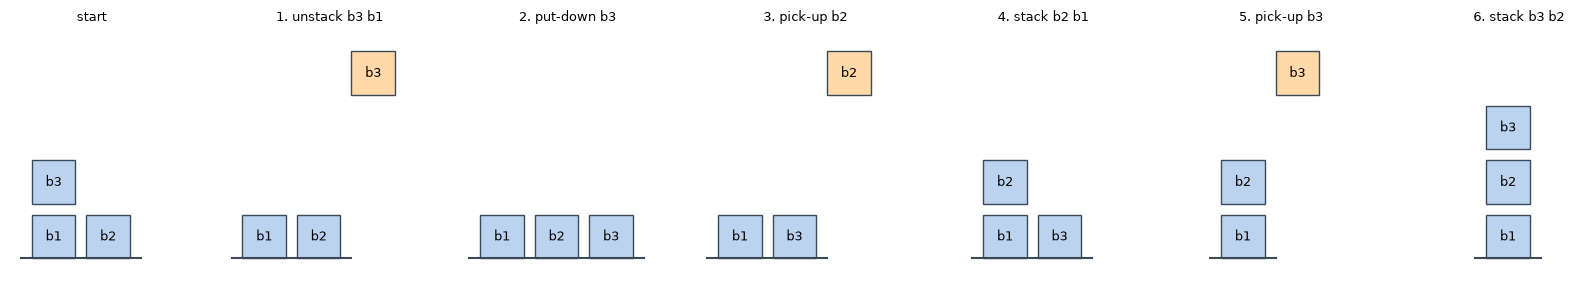

In [ ]:
# Go deeper. Needs matplotlib (the viz extra).
if IN_COLAB:
    import subprocess

    subprocess.run(["pip", "install", "-q", "matplotlib"], check=True)

steps = [action for _, action, _ in helpers.explain_plan(kg, "problem_3_1")]
try:
    import viz

    viz.draw_plan_states(DATA, steps)
except ImportError:
    print(
        "Install the viz extra to draw the plan: `pip install matplotlib` or `uv sync --extra viz`"
    )

---

## Recap and next

You answered both questions with one-line helper calls and drew the plan, no
SPARQL. The helpers wrap the SPARQL you write by hand in the notebooks that
follow.

| Notebook                             | Focus                                                                           |
| ------------------------------------ | ------------------------------------------------------------------------------- |
| **00 · Quickstart**                  | Ask both questions through one-line helpers, then see the plan _(you are here)_ |
| **01 · Ontology and KG foundations** | Load the ontology, build a KG from PDDL, query and reason over it               |
| **02 · Planner selection**           | Rank planners for a domain, then chart the field across IPC-2018                |
| **03 · Plan explanation**            | Read a plan's story, watch it run, and trace why its steps are ordered          |


> **Recommended next:** **01 · Ontology and KG foundations**, to see the ontology
> and SPARQL behind these helpers.
